# DeepLabV3 Segmentation Pipeline

This notebook contains:
- Dataset loader (image + mask)
- DeepLabV3 segmentation model
- Loss functions (BCE + Dice)
- IoU metrics
- Training loop
- Visualization utilities

**Make sure to set your data paths correctly before training!**

In [9]:
!pip install torch torchvision matplotlib pillow tqdm albumentations

In [3]:
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF

# ==========================
# CONFIGURE YOUR PATHS HERE
# ==========================

ROOT = Path("../seg_data")  # change if needed
IMG_DIR = ROOT / "images"
MASK_DIR = ROOT / "masks"

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
NUM_WORKERS = 4
NUM_EPOCHS = 45
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cpu


In [4]:
from torchvision.models.segmentation import deeplabv3_resnet50

def build_deeplab(num_classes=1, pretrained_backbone=True):
    # do not request incompatible weight enums — use no weights
    model = deeplabv3_resnet50(weights='DEFAULT')
    # replace the final classifier conv so output channels = num_classes
    in_channels = model.classifier[-1].in_channels
    model.classifier[-1] = nn.Conv2d(in_channels, num_classes, kernel_size=1)
    # adjust aux classifier if present
    if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
        try:
            in_ch_aux = model.aux_classifier[-1].in_channels
            model.aux_classifier[-1] = nn.Conv2d(in_ch_aux, num_classes, kernel_size=1)
        except Exception:
            pass
    return model


In [5]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

def bce_dice_loss(logits, targets, bce_weight=0.5):
    bce = nn.BCEWithLogitsLoss()(logits, targets)
    dice = DiceLoss()(logits, targets)
    return bce_weight * bce + (1 - bce_weight) * dice

def iou_score(logits, targets, thresh=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) >= thresh).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean().item()

In [6]:
def generate_splits(images_dir):
    valid_ext = (".png", ".jpg", ".jpeg")

    all_ids = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(valid_ext)
    ])

    # First split: train vs temp (val+test)
    train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, shuffle=True)

    # Second split temp → val + test (15% each)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, shuffle=True)

    return train_ids, val_ids, test_ids

train_ids, val_ids, test_ids = generate_splits("../seg_data/images")

In [7]:
import sys
sys.path.append("../src")
import importlib
import seg_dataset
importlib.reload(seg_dataset)

from seg_dataset import SegmentationDataset

def get_dataloaders(img_dir, mask_dir, batch_size=8, img_size=(300,300)):
    # --------------------------------------------------
    # 1. Get ALL filenames (fast even for 1500+ images)
    # --------------------------------------------------
    valid_ext = (".jpg", ".jpeg", ".png")
    all_ids = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(valid_ext)
    ])

    # --------------------------------------------------
    # 2. Train/Val/Test split 70/15/15
    # --------------------------------------------------
    train_ids, temp_ids = train_test_split(
        all_ids, test_size=0.30, shuffle=True, random_state=42
    )
    val_ids, test_ids = train_test_split(
        temp_ids, test_size=0.50, shuffle=True, random_state=42
    )

    print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

    # --------------------------------------------------
    # 3. Create separate dataset objects
    # --------------------------------------------------
    train_ds = SegmentationDataset(
        img_dir, mask_dir,
        img_size=img_size,
        augment=True,
        id_list=train_ids
    )

    val_ds = SegmentationDataset(
        img_dir, mask_dir,
        img_size=img_size,
        augment=False,
        id_list=val_ids
    )

    test_ds = SegmentationDataset(
        img_dir, mask_dir,
        img_size=img_size,
        augment=False,
        id_list=test_ids
    )

    # --------------------------------------------------
    # 4. Create data loaders
    # --------------------------------------------------
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=4, pin_memory=True, persistent_workers=True, drop_last=True
    )

    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True, persistent_workers=True, drop_last=False
    )

    test_loader = DataLoader(
        test_ds, batch_size=1, shuffle=False,
        num_workers=4, pin_memory=True, persistent_workers=True, drop_last=False
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(IMG_DIR, MASK_DIR, batch_size=BATCH_SIZE)

Train: 1100, Val: 236, Test: 236


In [14]:
def train_segmentation(train_loader, val_loader, epochs=NUM_EPOCHS, lr=1e-4, patience=7):
    records = []
    model = build_deeplab(1).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_iou = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0
        epoch_start = time.time()
        for batch_idx, (imgs, masks) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} training")):
            # inside your training loop, before `out = model(imgs)['out']`

            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)["out"]
            loss = bce_dice_loss(out, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            ious = iou_score(out.detach(), masks.detach())
            mean_iou = float(np.mean(np.asarray(ious)))

            # record batch-level row(s)
            records.append({
                "phase": "train",
                "epoch": epoch,
                "batch_idx": batch_idx,
                "batch_size": imgs.size(0),
                "loss": float(loss.item()),
                "mean_iou": mean_iou,
                "time": time.time() - epoch_start
            })
        

        model.eval()
        val_losses = []
        val_iou_scores = []
        with torch.no_grad():
            for batch_idx, (imgs, masks) in enumerate(val_loader):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)["out"]
                
                loss = bce_dice_loss(out, masks)
                val_losses.append(float(loss.item()))
                
                ious =  iou_score(out.detach(), masks.detach())
                val_iou_scores.append(float(np.mean(np.asarray(ious))))
                
        val_loss = float(np.mean(val_losses))
        val_iou  = float(np.mean(val_iou_scores))
                
        records.append({
            "phase": "val",
            "epoch": epoch,
            "batch_idx": None,
            "batch_size": None,
            "loss": val_loss,
            "mean_iou": val_iou,
            "time": time.time() - epoch_start
        })

        print(f"Epoch {epoch}, Loss: {running_loss:.4f}, IoU: {val_iou:.4f}")
        
        scheduler.step(val_iou)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), "best_deeplab.pt")
            print("✔ Saved best model.")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print("\n⛔ Early stopping triggered.")
                break

    return model, records

model, records = train_segmentation(train_loader, val_loader, epochs=NUM_EPOCHS, lr=1e-4)

df = pd.DataFrame.from_records(records)
df.to_csv("training_metrics.csv", index=False)
print("Saved training_metrics.csv")

Epoch 1 training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 1, Loss: 71.0884, IoU: 0.5071
✔ Saved best model.


Epoch 2 training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 2, Loss: 57.2570, IoU: 0.5698
✔ Saved best model.


Epoch 3 training:   0%|          | 0/137 [00:00<?, ?it/s]

...

Epoch 20, Loss: 31.4989, IoU: 0.6661
Patience: 5/7


Epoch 21 training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 21, Loss: 30.8977, IoU: 0.6592
Patience: 6/7


Epoch 22 training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 22, Loss: 30.5680, IoU: 0.6534
Patience: 7/7

⛔ Early stopping triggered.
Saved training_metrics.csv


/var/folders/v0/2gz3w_2x1p314gn8t7w9j4f40000gn/T/ipykernel_48348/4070934147.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, 

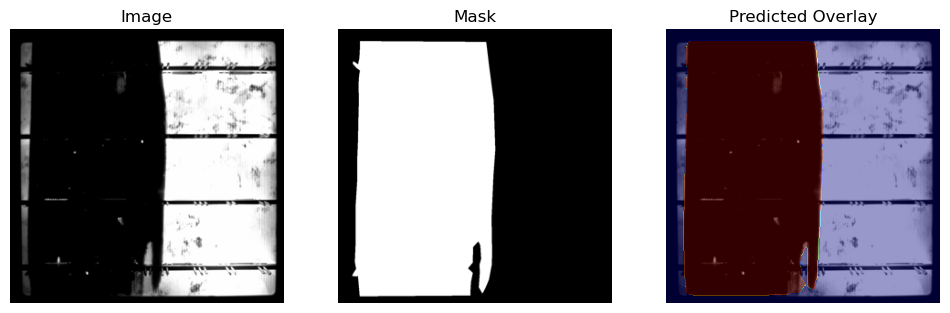

In [17]:
def visualize_prediction(img_path, mask_path, model_path="best_deeplab.pt", img_size=IMG_SIZE, thresh=0.5):
    model = build_deeplab(1)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE).eval()

    img = Image.open(img_path).convert("RGB").resize(img_size)
    mask = Image.open(mask_path).convert("L").resize(img_size)

    img_t = TF.to_tensor(img)
    img_t = TF.normalize(img_t, mean=[0.5]*3, std=[0.5]*3).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(img_t)["out"]
        prob = torch.sigmoid(out)[0,0].cpu().numpy()
        pred = (prob >= thresh)

    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(img); ax[0].set_title("Image"); ax[0].axis("off")
    ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Mask"); ax[1].axis("off")
    ax[2].imshow(img); ax[2].imshow(pred, cmap="jet", alpha=0.4); ax[2].set_title("Predicted Overlay"); ax[2].axis("off")
    plt.show()
    
visualize_prediction(
    img_path="../seg_data/images/0013.jpg",
    mask_path="../seg_data/masks/0013.jpg",
    model_path="best_deeplab.pt"
)

In [ ]:
# --------------------------
# Load trained model
# --------------------------
def load_model(model_path="best_deeplab.pt"):
    model = build_deeplab(num_classes=1)   # same function you used in training
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model


# --------------------------
# Single image prediction
# --------------------------
def predict_mask(model, img_tensor):
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(DEVICE))["out"]
        prob = torch.sigmoid(out)[0, 0]        
        return (prob > 0.5).float().cpu().numpy()


# --------------------------
# Load + preprocess image/mask
# --------------------------
def load_image_mask(img_path, mask_path, img_size=300):
    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    img = np.array(img)
    mask = np.array(mask)

    # same transforms as training (WITHOUT augmentation)
    transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(),
        ToTensorV2(),
    ])

    data = transform(image=img, mask=mask)
    img_tensor = data["image"]
    mask_tensor = data["mask"] / 255.0  # normalize to 0–1
    return img_tensor, mask_tensor.numpy()


# --------------------------
# Compute IoU
# --------------------------
def compute_iou(pred, true):
    pred = pred.astype(bool)
    true = true.astype(bool)

    inter = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()

    if union == 0:
        return 1.0  # both blank → perfect IoU
    return inter / union

import numpy as np
import torch

def compute_metrics_from_logits(logits, targets, thresh=0.5, eps=1e-6):
    """
    logits: raw model output, shape (1, 1, H, W)
    targets: ground truth mask tensor, shape (1, 1, H, W)
    """

    # Apply sigmoid + threshold (same as your iou_score fn)
    preds = (torch.sigmoid(logits) >= thresh).float()
    preds = preds.view(-1).cpu().numpy()
    true  = targets.view(-1).float().cpu().numpy()

    # Compute TP, FP, FN
    tp = np.logical_and(preds == 1, true == 1).sum()
    fp = np.logical_and(preds == 1, true == 0).sum()
    fn = np.logical_and(preds == 0, true == 1).sum()

    # IoU
    inter = tp
    union = tp + fp + fn
    iou = inter / (union + eps)

    # Dice coefficient
    dice = (2 * tp) / (2 * tp + fp + fn + eps)

    # Precision
    precision = tp / (tp + fp + eps)

    # Recall
    recall = tp / (tp + fn + eps)

    # F1 score
    f1 = (2 * precision * recall) / (precision + recall + eps)

    return {
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }



# --------------------------
# MAIN evaluation function
# --------------------------
def evaluate_model(test_loader, thresh=0.5):

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    test_model = load_model("best_deeplab.pt")
    test_model.eval()

    results = []
    iou_scores = []

    with torch.no_grad():
        for idx, (imgs, masks) in enumerate(tqdm(test_loader, desc="Evaluating (Loader)")):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            # Get prediction
            out = test_model(imgs)["out"]
        
            
            metrics = compute_metrics_from_logits(out, masks, thresh=thresh)
            metrics["index"] = idx


            # Compute IoU
            iou = iou_score(out.detach(), masks.detach())
            iou_scores.append(iou)

            results.append({
                "index": idx,
                "iou": iou
            })
            
            results.append(metrics)


    df = pd.DataFrame(results)
    df.to_csv("test_results_loader.csv", index=False)
    
    mean_results = df.mean(numeric_only=True)

    print("\n=========== FINAL METRICS ===========")
    print(mean_results)
    print("Saved test_metrics.csv")
    print("====================================")

    return df, mean_results

df, mean_results = evaluate_model(test_loader)

print(df)          # prints the full table of per-image IoU
print(mean_results)

/var/folders/v0/2gz3w_2x1p314gn8t7w9j4f40000gn/T/ipykernel_70418/1961490720.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, 

Evaluating (Loader):   0%|          | 0/236 [00:00<?, ?it/s]